我们在此,加入一个系数,用来衡量价格偏离价值.基础模型预测乘以这个系数,作为新的预测值,看是否会有所改善.

In [2]:
from utils.common import *

In [3]:
data_set = pd.read_pickle('./src/pickle/Dataset.pkl')

In [5]:
# 路径沿用你之前的项目设置：工作目录为项目根目录
data_set = pd.read_pickle('./src/pickle/Dataset.pkl')

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-5, 1, 1000)
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

In [6]:
# 前提：data_set 已修复之前发现的非交易日、bfill 问题
X = data_set.X.copy()
Y = data_set.Y.copy()

# 上一交易日的宏观变量 → 当天股价
data = pd.concat([
    X.shift(1),
    Y.rename('actual_price')
], axis=1).dropna()

# 按日期划分
train = data.loc[data.index <= '2024-09-30']
test  = data.loc[data.index >  '2024-09-30']

X_train = train[X.columns]
Y_train = train['actual_price']

X_test = test[X.columns]
Y_test = test['actual_price']

# 沿用你之前定义的 GridSearchCV：StandardScaler + Lasso
grid_lasso.fit(X_train, Y_train)

# 保留实际价格、基础预测价格、对应系数
result_train = Y_train.to_frame()
result_train['base_price'] = grid_lasso.predict(X_train)

result_test = Y_test.to_frame()
result_test['base_price'] = grid_lasso.predict(X_test)

for result in [result_train, result_test]:
    # 倍数模型要求基础价格为正；非正预测不计算系数
    base = result['base_price'].where(result['base_price'] > 0)
    result['k'] = result['actual_price'] / base

display(result_train)
display(result_test)

,actual_price,base_price,k
2012-05-10,4.26,4.391923,0.969962
2012-05-11,4.20,4.505882,0.932115
2012-05-14,4.15,4.316524,0.961422
2012-05-15,4.14,4.016490,1.030751
2012-05-16,4.08,3.896872,1.046994
...,...,...,...
2024-09-25,16.92,17.092396,0.989914
2024-09-26,17.37,17.274134,1.005550
2024-09-27,17.51,17.840140,0.981495
2024-09-29,18.14,17.740008,1.022547


,actual_price,base_price,k
2024-10-01,17.96,18.166910,0.988611
2024-10-02,17.96,18.157958,0.989098
2024-10-03,17.96,18.323848,0.980143
2024-10-04,17.96,18.134768,0.990363
2024-10-07,17.96,18.300486,0.981395
...,...,...,...
2026-07-17,28.36,30.610353,0.926484
2026-07-20,29.35,30.136753,0.973894
2026-07-21,30.21,30.320538,0.996354
2026-07-22,32.20,31.069387,1.036390


在这个项目中,我们应该把K值作为预测值Y,找出多个信息来

我们先后选市场趋势,市场波动,成交活跃度和同行表现四个因子

In [ ]:
# 1. 读取你项目里已有的数据
stock_data = pd.read_pickle('./data/stock_data.pkl')

stocks = {}
for name, frame in stock_data.items():
    frame = frame.copy()
    frame['date'] = pd.to_datetime(frame['date'])
    stocks[name] = frame.set_index('date').sort_index()

zijin = stocks['紫金矿业']

market = pd.read_csv(
    './data/A_500.csv',
    parse_dates=['date']
).set_index('date').sort_index()['close']


# 2. 构造四个因子
factors = pd.DataFrame(index=zijin.index)

# 市场过去20日涨幅
factors['market_return20'] = market.pct_change(
    periods=20, fill_method=None
)

# 市场过去5个交易日的波动率（日收益率的标准差）
market_daily_return = market.pct_change(fill_method=None)
factors['market_volatility5'] = (
    market_daily_return.rolling(5).std()
)

# 紫金换手率相对近期平均水平的变化
turnover = zijin['turnover']
factors['turnover_ratio'] = (
    turnover / turnover.rolling(20).mean() - 1
)

# 剔除紫金，计算其他股票的20日平均涨幅
peer_prices = pd.DataFrame({
    name: frame['close']
    for name, frame in stocks.items()
    if name != '紫金矿业'
})

factors['peer_return20'] = (
    peer_prices
    .pct_change(periods=20, fill_method=None)
    .mean(axis=1)
)

  
# 3. 上一交易日的信息 → 当天的 k
# 与之前按“被预测日期”存放的 result_train/result_test 对应
factors = factors.shift(1)


# 4. 与已经计算好的 k 对齐
train_k = factors.join(result_train[['k']], how='inner')
test_k = factors.join(result_test[['k']], how='inner')

train_k = train_k.replace([np.inf, -np.inf], np.nan).dropna()
test_k = test_k.replace([np.inf, -np.inf], np.nan).dropna()

X_train_k = train_k[factors.columns]
Y_train_k = train_k['k']

X_test_k = test_k[factors.columns]
Y_test_k = test_k['k']

display(train_k.head())

In [ ]:
display(X_train_k)

,market_return20,market_volatility20,turnover_ratio,peer_return20
2012-06-01,-0.014192,0.010227,-0.234473,-0.019385
2012-06-04,-0.029044,0.009936,0.391434,0.099250
2012-06-05,-0.058171,0.011482,0.808183,0.061547
2012-06-06,-0.054848,0.011514,-0.138471,-0.019469
2012-06-07,-0.037456,0.010907,1.218260,0.031183
...,...,...,...,...
2024-09-24,-0.024328,0.007450,-0.031236,-0.043100
2024-09-25,0.013562,0.012329,0.675365,-0.022521
2024-09-26,0.027311,0.012648,0.809121,0.017091
2024-09-27,0.077816,0.015433,0.372960,0.045418


In [11]:
Y_train_k

2012-06-01    1.181922
2012-06-04    1.148526
2012-06-05    1.127730
2012-06-06    1.159374
2012-06-07    1.037713
                ...   
2024-09-24    0.996580
2024-09-25    0.989914
2024-09-26    1.005550
2024-09-27    0.981495
2024-09-30    1.010094
Name: k, Length: 2969, dtype: float64

RMSE： 0.16468088949010895
R²： -0.535394056659279


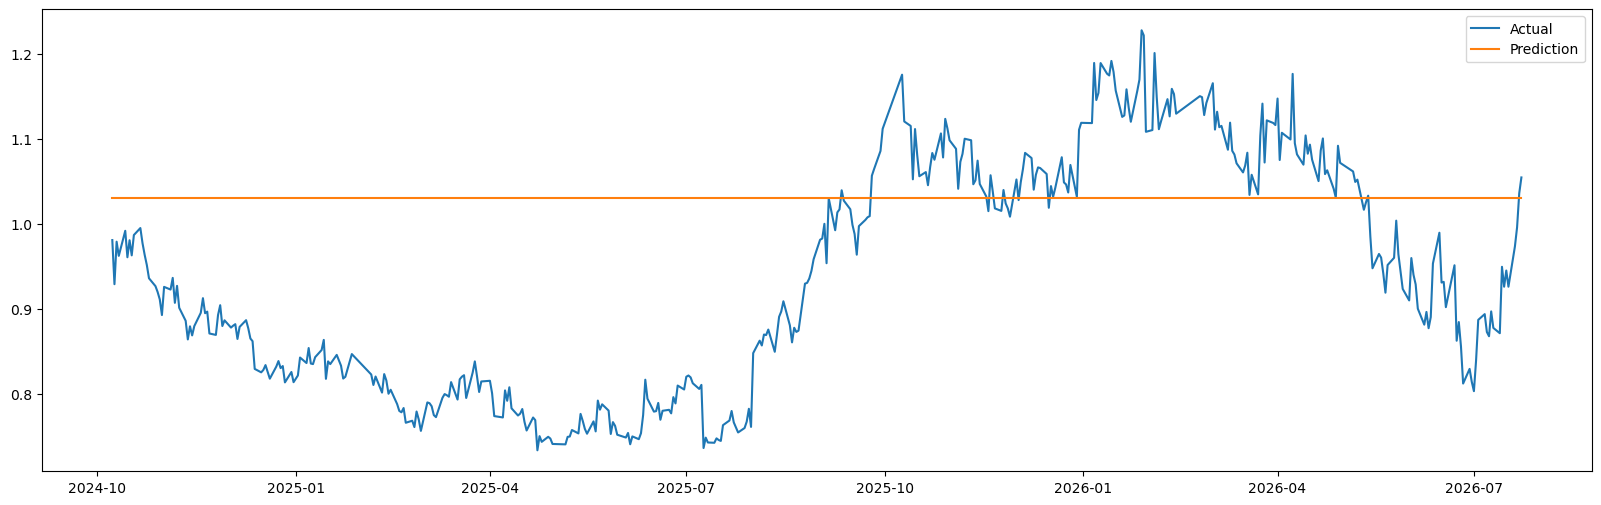

market_return20       -0.0
market_volatility20    0.0
turnover_ratio         0.0
peer_return20         -0.0
dtype: float64

In [12]:
Lasso_test(X_train_k,Y_train_k,X_test_k,Y_test_k)

lasso的模型把这些因子都压缩成了0,导致了直线,我们用普通的OLS试一下.

In [13]:
from sklearn.linear_model import LinearRegression

model_k = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

model_k.fit(X_train_k, Y_train_k)
k_pred = model_k.predict(X_test_k)

print('RMSE:', np.sqrt(mean_squared_error(Y_test_k, k_pred)))
print('R²:', r2_score(Y_test_k, k_pred))

display(pd.Series(
    model_k.named_steps['model'].coef_,
    index=X_train_k.columns
))

RMSE: 0.16572104291269682
R²: -0.5548509468617546


market_return20       -0.009382
market_volatility20    0.044012
turnover_ratio         0.008336
peer_return20          0.005399
dtype: float64

仍然没用.看来大盘涨幅,波动与其他股票的涨幅,换手率,用20日平均没有用.换成5日查看一下.

In [16]:
# 1. 读取你项目里已有的数据
stock_data = pd.read_pickle('./data/stock_data.pkl')

stocks = {}
for name, frame in stock_data.items():
    frame = frame.copy()
    frame['date'] = pd.to_datetime(frame['date'])
    stocks[name] = frame.set_index('date').sort_index()

zijin = stocks['紫金矿业']

market = pd.read_csv(
    './data/A_500.csv',
    parse_dates=['date']
).set_index('date').sort_index()['close']


# 2. 构造四个因子
factors = pd.DataFrame(index=zijin.index)

# 市场过去5日涨幅
factors['market_return20'] = market.pct_change(
    periods=5, fill_method=None
)

# 市场过去5日的波动率
market_daily_return = market.pct_change(fill_method=None)
factors['market_volatility5'] = (
    market_daily_return.rolling(5).std()
)

# 紫金换手率相对近期平均水平的变化
turnover = zijin['turnover']
factors['turnover_ratio'] = (
    turnover / turnover.rolling(5).mean() - 1
)

# 剔除紫金，计算其他股票的5日平均涨幅
peer_prices = pd.DataFrame({
    name: frame['close']
    for name, frame in stocks.items()
    if name != '紫金矿业'
})

factors['peer_return5'] = (
    peer_prices
    .pct_change(periods=5, fill_method=None)
    .mean(axis=1)
)


# 3. 上一交易日的信息 → 当天的 k
# 与之前按“被预测日期”存放的 result_train/result_test 对应
factors = factors.shift(1)


# 4. 与已经计算好的 k 对齐
train_k = factors.join(result_train[['k']], how='inner')
test_k = factors.join(result_test[['k']], how='inner')

train_k = train_k.replace([np.inf, -np.inf], np.nan).dropna()
test_k = test_k.replace([np.inf, -np.inf], np.nan).dropna()

X_train_k = train_k[factors.columns]
Y_train_k = train_k['k']

X_test_k = test_k[factors.columns]
Y_test_k = test_k['k']

display(train_k.head())

,market_return20,market_volatility5,turnover_ratio,peer_return5,k
2012-05-10,-0.007035,0.010418,-0.025618,-0.014287,0.969962
2012-05-11,-0.009722,0.010210,-0.272701,0.003575,0.932115
2012-05-14,-0.024934,0.008240,-0.095950,0.085861,0.961422
2012-05-15,-0.034417,0.007127,-0.017087,0.048218,1.030751
2012-05-16,-0.031345,0.007729,-0.155076,-0.043205,1.046994


RMSE： 0.16330668986282146
R²： -0.5098764069724901


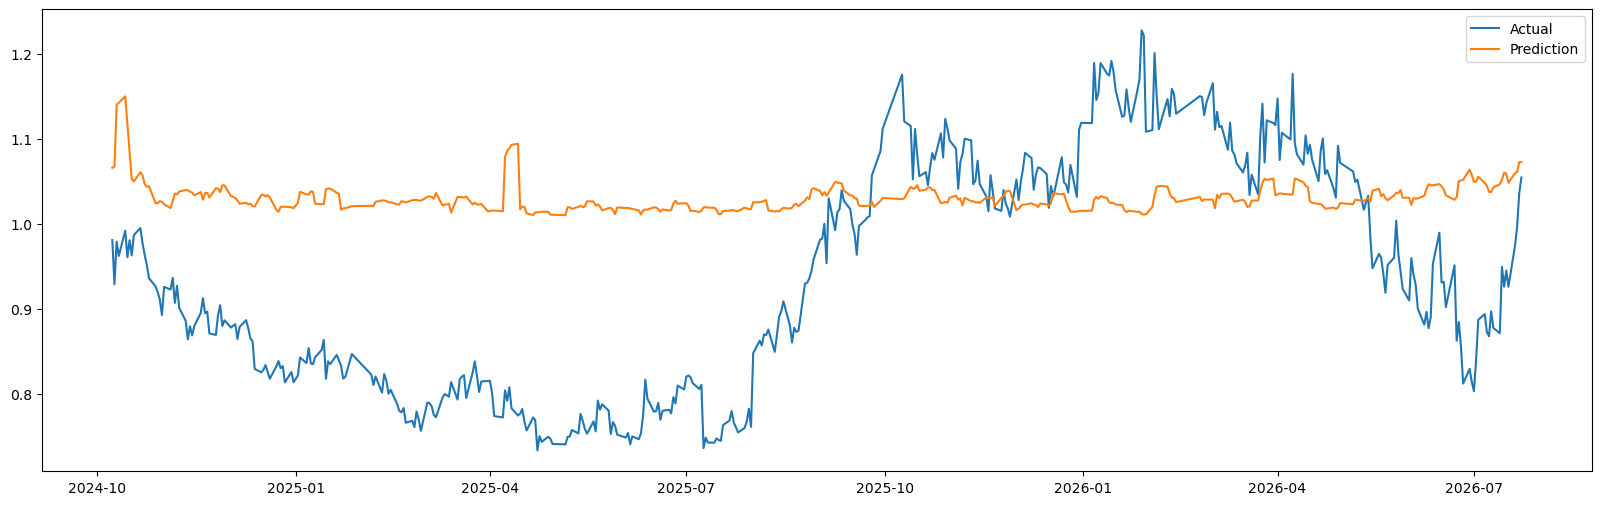

market_return20      -0.000000
market_volatility5    0.015579
turnover_ratio        0.000000
peer_return5          0.000000
dtype: float64

In [17]:
Lasso_test(X_train_k, Y_train_k, X_test_k, Y_test_k)

RMSE： 0.19644435440098518
R²： 0.02001584080053742


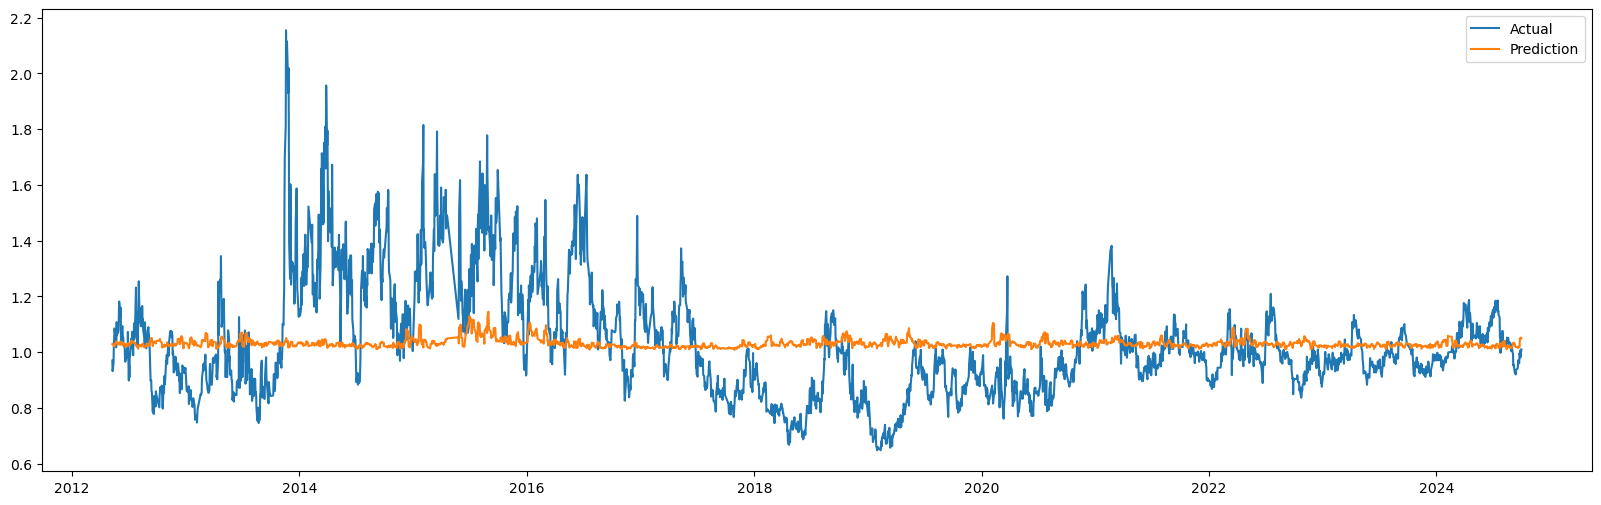

market_return20      -0.000000
market_volatility5    0.015579
turnover_ratio        0.000000
peer_return5          0.000000
dtype: float64

In [18]:
Lasso_test(X_train_k, Y_train_k, X_train_k, Y_train_k)

再用训练集反查了一下,市场的波动程度略微有一点用,保留下来.

In [20]:
def calculate_MACD(df, nslow=26, nfast=12):
    emaslow = df.ewm(span=nslow, min_periods=nslow, adjust=True, ignore_na=False).mean()
    emafast = df.ewm(span=nfast, min_periods=nfast, adjust=True, ignore_na=False).mean()
    dif = emafast - emaslow
    Dea = dif.ewm(span=9, min_periods=9, adjust=True, ignore_na=False).mean()
    Histo = dif - Dea
    return dif, Histo

RMSE： 0.16376921653127197
R²： -0.5184412375990635


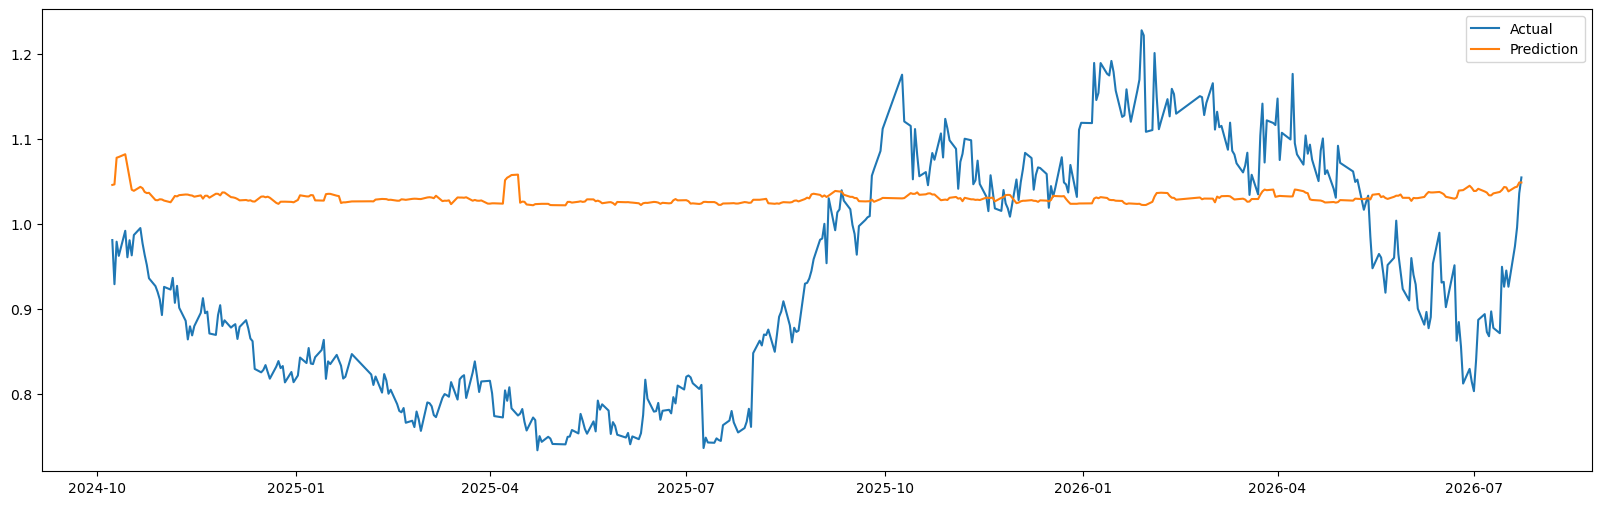

market_return20      -0.00000
market_volatility5    0.00673
turnover_ratio        0.00000
peer_return5          0.00000
rsi                   0.00000
dif_relative         -0.00000
macd_relative         0.00000
dtype: float64

In [21]:
# 1. 用原始股价计算指标，不要用 k 计算
price = data_set.Y.copy().sort_index()

rsi = calculate_wilder_RSI(price)
dif, macd = calculate_MACD(price)

technical = pd.DataFrame({
    'rsi': rsi,
    'dif_relative': dif / price,
    'macd_relative': macd / price
})

# 上一期指标 → 当期 k
technical = technical.shift(1)


# 2. 加入当前第二层模型的因子
# X_train_k / X_test_k 之前已经做过滞后，不要再次 shift
train_new = (
    X_train_k
    .join(technical)
    .join(Y_train_k.rename('k'))
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

test_new = (
    X_test_k
    .join(technical)
    .join(Y_test_k.rename('k'))
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X_train_new = train_new.drop(columns='k')
Y_train_new = train_new['k']

X_test_new = test_new.drop(columns='k')
Y_test_new = test_new['k']


# 3. 预测 k
Lasso_test(
    X_train_new, Y_train_new,
    X_test_new, Y_test_new
)

macd与rsi指标也没用

准备新加入财报的指标,有可能是宏观指标预测模型没有跟上价格变化,而非修正系数没有跟上.

如果将宏观预测模型中加入扣非净利润,作为股价预测的一个基础,用线性模型是可行的.但是对于一些股票具有增长性,又应该如何处理?

扣非净利润 TTM 缺失数： 0
训练集： (3349, 8)
测试集： (486, 8)


,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,扣非净利润_TTM
2024-09-24,1410.109436,100.370003,2.0728,3.74,75.29,4.4620,1663.550249,273.942056
2024-09-25,1429.055599,100.919998,2.0437,3.79,75.40,4.4605,1668.570015,273.942056
2024-09-26,1489.467659,100.559998,2.0787,3.79,73.06,4.6100,1675.283921,273.942056
2024-09-27,1560.147472,100.419998,2.1714,3.75,71.63,4.5995,1659.220763,273.942056
2024-09-29,1700.364180,100.779999,2.2534,3.81,72.35,4.5530,1654.075534,273.942056


RMSE： 3.9148645702577647
R²： 0.7614883043495366


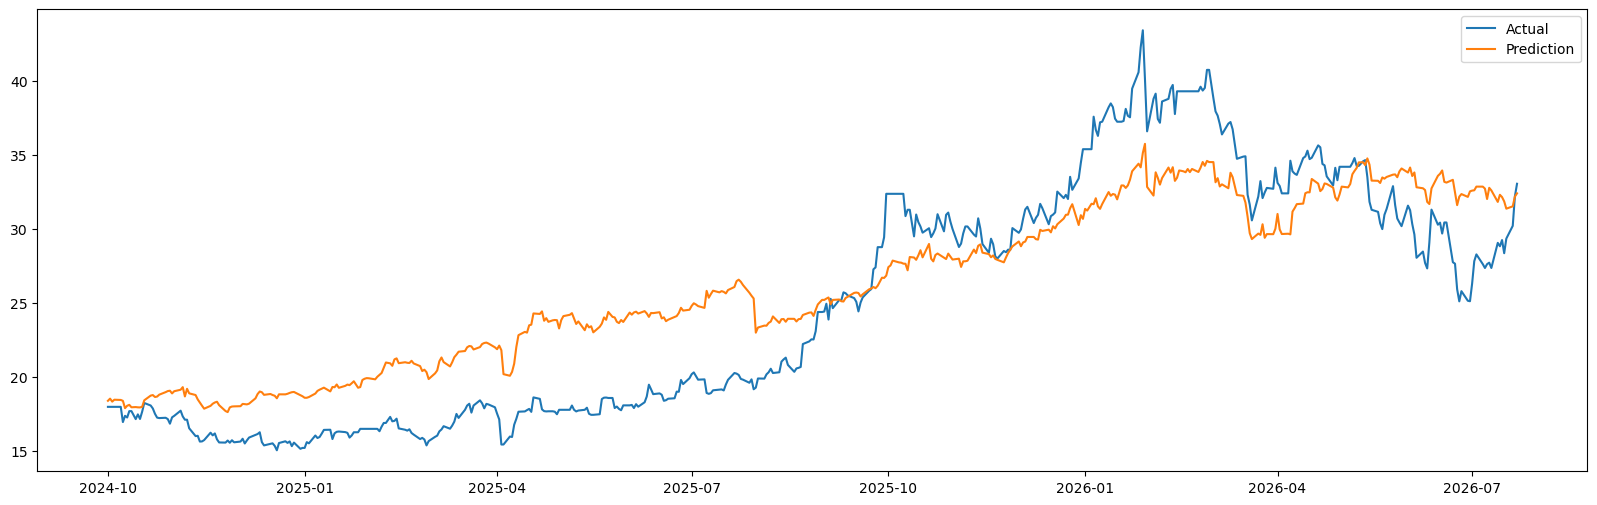

A_500                   1.212849
Dollar Index           -0.956776
cn_10y_rate            -0.996754
us_10y_rate             1.557620
brent                  -0.831509
Copper Futures Price    1.250922
Gold Futures Price      1.245623
扣非净利润_TTM               0.472208
dtype: float64

In [22]:
# ===== 1. 导入依赖、定位项目目录 =====
import sys
from pathlib import Path
import pandas as pd

# 无论 notebook 在项目根目录还是 notebooks 子目录，都找到项目根目录
ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src/pickle/Dataset.pkl").exists()
)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.common import Lasso_test


# ===== 2. 读取原来的宏观变量和股价 =====
data_set = pd.read_pickle(ROOT / "src/pickle/Dataset.pkl")

X = data_set.X.copy()
Y = data_set.Y.copy()

X.index = pd.to_datetime(X.index).normalize()
Y.index = pd.to_datetime(Y.index).normalize()

X = X.sort_index()
Y = Y.sort_index()


# ===== 3. 读取扣非净利润 TTM =====
financial = pd.read_excel(
    ROOT / "data/Zijin-fundamentals.xlsx",
    sheet_name="日频特征",
    parse_dates=["date"]
).set_index("date")

financial.index = financial.index.normalize()

# 已按公告时间对齐，直接加入；金额单位换为亿元
X["扣非净利润_TTM"] = (
    financial["adj_profit_ttm_cny"].reindex(X.index) / 1e8
)

print("扣非净利润 TTM 缺失数：", X["扣非净利润_TTM"].isna().sum())


# ===== 4. 用今天的变量预测下一个交易日的价格 =====
target_date = pd.Series(Y.index, index=Y.index).shift(-1)
Y = Y.shift(-1).rename("明日股价")

# 一起对齐，去掉无法用于训练的行，包括最后一天
model_data = X.join(Y).dropna()

X = model_data.drop(columns="明日股价")
Y = model_data["明日股价"]
target_date = target_date.reindex(X.index)


# ===== 5. 划分训练集、测试集 =====
cutoff = pd.Timestamp("2024-09-30")

# 训练标签也必须在截止日期以内
train_mask = (X.index <= cutoff) & (target_date <= cutoff)
test_mask = X.index > cutoff

X_train = X.loc[train_mask]
Y_train = Y.loc[train_mask]

X_test = X.loc[test_mask]
Y_test = Y.loc[test_mask]

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)
display(X_train.tail())


# ===== 6. 沿用你 common.py 中的模型 =====
# 函数内部已包含 StandardScaler、时间序列交叉验证和 Lasso 调参
Lasso_test(X_train, Y_train, X_test, Y_test)

与_02相比,模型的预测效果反而更差了,R^2从.80到.76,但是从图中看出来,预测效果似乎与测试集的选择又高度相关.  
假设从2026年4月到7月新模型的预测效果并不好.因为模型预测的时候,我们加入了年报中的数据,它一个季度更新一次,在数据集中,最新更新的季报是2026年4月22日公布的.因此,我们对5月到7月的信息具有滞后性.因此我们在测试集,我们选择截止到5月份,或者新加入2026年的中报数据.

扣非净利润 TTM 缺失数： 0
训练集： (3349, 8)
测试集： (447, 8)


,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,扣非净利润_TTM
2024-09-24,1410.109436,100.370003,2.0728,3.74,75.29,4.4620,1663.550249,273.942056
2024-09-25,1429.055599,100.919998,2.0437,3.79,75.40,4.4605,1668.570015,273.942056
2024-09-26,1489.467659,100.559998,2.0787,3.79,73.06,4.6100,1675.283921,273.942056
2024-09-27,1560.147472,100.419998,2.1714,3.75,71.63,4.5995,1659.220763,273.942056
2024-09-29,1700.364180,100.779999,2.2534,3.81,72.35,4.5530,1654.075534,273.942056


RMSE： 3.8708859074458517
R²： 0.7802182870284322


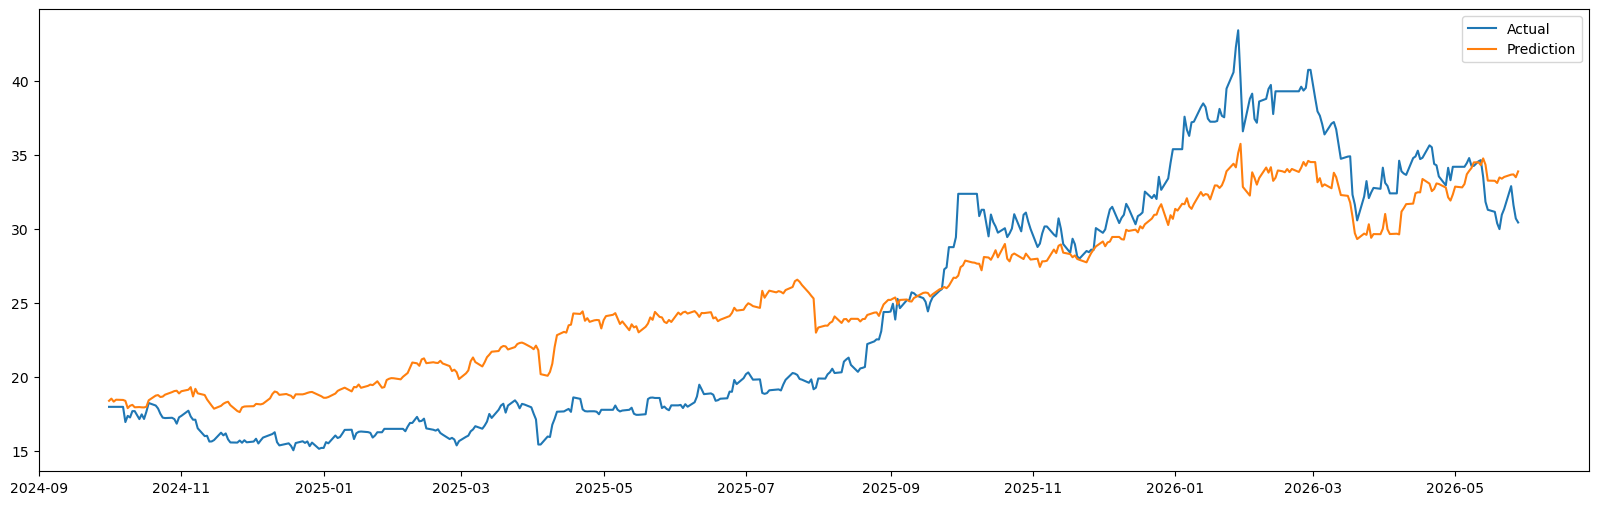

A_500                   1.212849
Dollar Index           -0.956776
cn_10y_rate            -0.996754
us_10y_rate             1.557620
brent                  -0.831509
Copper Futures Price    1.250922
Gold Futures Price      1.245623
扣非净利润_TTM               0.472208
dtype: float64

In [24]:
# ===== 1. 导入依赖、定位项目目录 =====
import sys
from pathlib import Path
import pandas as pd

# 无论 notebook 在项目根目录还是 notebooks 子目录，都找到项目根目录
ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src/pickle/Dataset.pkl").exists()
)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.common import Lasso_test


# ===== 2. 读取原来的宏观变量和股价 =====
data_set = pd.read_pickle(ROOT / "src/pickle/Dataset.pkl")

X = data_set.X.copy()
Y = data_set.Y.copy()

X.index = pd.to_datetime(X.index).normalize()
Y.index = pd.to_datetime(Y.index).normalize()

X = X.sort_index()
Y = Y.sort_index()


# ===== 3. 读取扣非净利润 TTM =====
financial = pd.read_excel(
    ROOT / "data/Zijin-fundamentals.xlsx",
    sheet_name="日频特征",
    parse_dates=["date"]
).set_index("date")

financial.index = financial.index.normalize()

# 已按公告时间对齐，直接加入；金额单位换为亿元
X["扣非净利润_TTM"] = (
    financial["adj_profit_ttm_cny"].reindex(X.index) / 1e8
)

print("扣非净利润 TTM 缺失数：", X["扣非净利润_TTM"].isna().sum())


# ===== 4. 用今天的变量预测下一个交易日的价格 =====
target_date = pd.Series(Y.index, index=Y.index).shift(-1)
Y = Y.shift(-1).rename("明日股价")

# 一起对齐，去掉无法用于训练的行，包括最后一天
model_data = X.join(Y).dropna()

X = model_data.drop(columns="明日股价")
Y = model_data["明日股价"]
target_date = target_date.reindex(X.index)


# ===== 5. 划分训练集、测试集 =====
cutoff = pd.Timestamp("2024-09-30")
test_end = pd.Timestamp("2026-05-31")

train_mask = (X.index <= cutoff) & (target_date <= cutoff)

test_mask = (
    (X.index > cutoff)
    & (X.index <= test_end)
    & (target_date <= test_end)
)

X_train = X.loc[train_mask]
Y_train = Y.loc[train_mask]

X_test = X.loc[test_mask]
Y_test = Y.loc[test_mask]

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)
display(X_train.tail())


# ===== 6. 沿用你 common.py 中的模型 =====
# 函数内部已包含 StandardScaler、时间序列交叉验证和 Lasso 调参
Lasso_test(X_train, Y_train, X_test, Y_test)

即使抛开了波动较大的时期,总体的预测效果仍然是不如原模型的.扣非净利润也无法解释较大的波动.且扣非净利润不会经常变,用基本面来找出这一段时间的非理性上涨并不可行.或许这个模型更加接近实际的趋势,但对于股价预测效果更差.  
至于成长的预期,也与年报的发布息息相关.我也不认为是成长型会导致股价的距离波动.

再试一下当期的扣非净利润,看看是否能更好的解释冲量.紫金矿业的营收没有明显的季节性.

RMSE： 3.77110862671984
R²： 0.7914025970946292


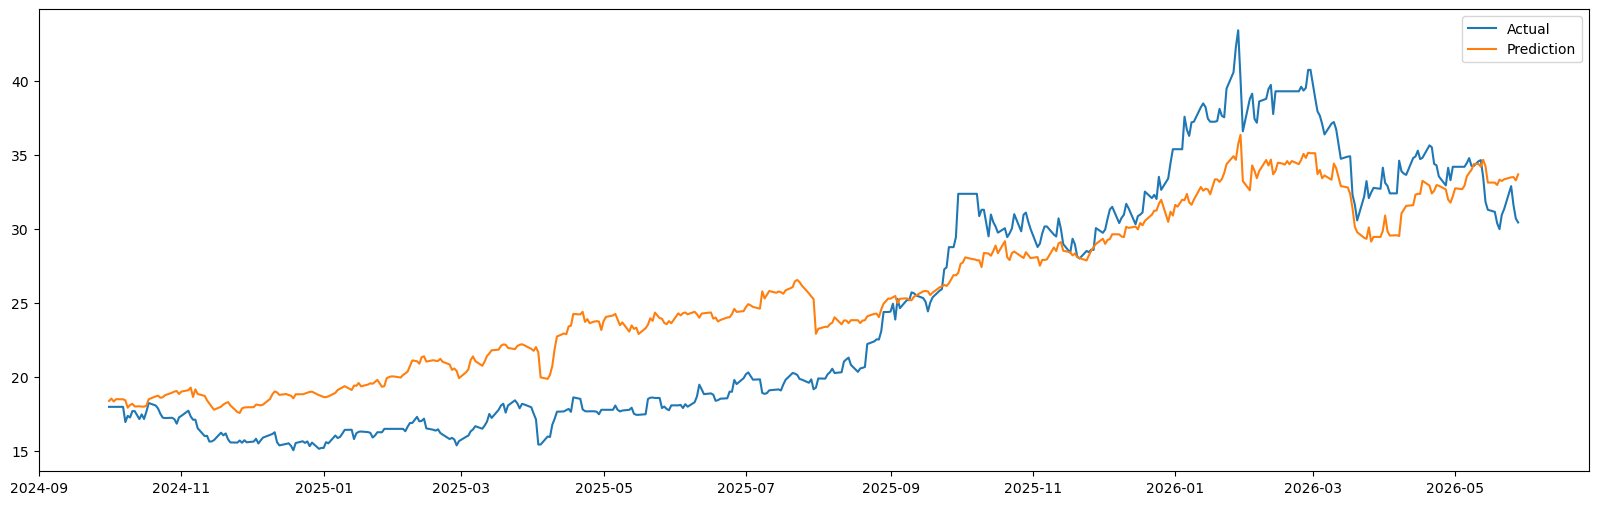

A_500                   1.212515
Dollar Index           -0.913468
cn_10y_rate            -1.049613
us_10y_rate             1.663590
brent                  -0.775340
Copper Futures Price    1.271859
Gold Futures Price      1.363418
归母净利润_单季                0.199371
dtype: float64

In [26]:
# ===== 1. 恢复原来的宏观变量和股价 =====
X = data_set.X.copy()
Y = data_set.Y.copy()

X.index = pd.to_datetime(X.index).normalize()
Y.index = pd.to_datetime(Y.index).normalize()

X = X.sort_index()
Y = Y.sort_index()


# ===== 2. 读取单季度归母净利润 =====
financial = pd.read_excel(
    ROOT / "data/Zijin-fundamentals.xlsx",
    sheet_name="季度财务",
    parse_dates=["公告后可用日期_日历日"]
)

profit = financial[
    ["公告后可用日期_日历日", "归母净利润_单季_元"]
].rename(columns={
    "公告后可用日期_日历日": "available_from",
    "归母净利润_单季_元": "归母净利润_单季"
})

# 元转为亿元
profit["归母净利润_单季"] /= 1e8
profit = profit.sort_values("available_from")


# ===== 3. 按可用日期匹配，每天使用最近已公告的利润 =====
X = pd.merge_asof(
    X.rename_axis("date").reset_index().sort_values("date"),
    profit,
    left_on="date",
    right_on="available_from",
    direction="backward"
).set_index("date").drop(columns="available_from")


# ===== 4. 今日变量预测下一交易日股价 =====
target_date = pd.Series(Y.index, index=Y.index).shift(-1)
Y = Y.shift(-1).rename("明日股价")

model_data = X.join(Y).dropna()

X = model_data.drop(columns="明日股价")
Y = model_data["明日股价"]
target_date = target_date.reindex(X.index)


# ===== 5. 划分训练集、测试集 =====
cutoff = pd.Timestamp("2024-09-30")
test_end = pd.Timestamp("2026-05-31")

train_mask = (
    (X.index <= cutoff)
    & (target_date <= cutoff)
)

test_mask = (
    (X.index > cutoff)
    & (X.index <= test_end)
    & (target_date <= test_end)
)

X_train = X.loc[train_mask]
Y_train = Y.loc[train_mask]

X_test = X.loc[test_mask]
Y_test = Y.loc[test_mask]


# ===== 6. 沿用原来的标准化和 Lasso 调参 =====
Lasso_test(X_train, Y_train, X_test, Y_test)

单季的效果更好一点,但是仍然无法解释偏离的情况.

假如说,我们的训练集太过久远,形式已经发生了转变,我们用更早的数据来训练会怎么样?选取24年9月30日前三年作为训练集,看看是否有所改善.

此外,紫金矿业的营收占比可能在变化.我们可以根据年报的披露时间,增加一个交互项,将金价,铜价与业务占比联系起来.

RMSE： 5.377271405334264
R²： 0.5758741663838882


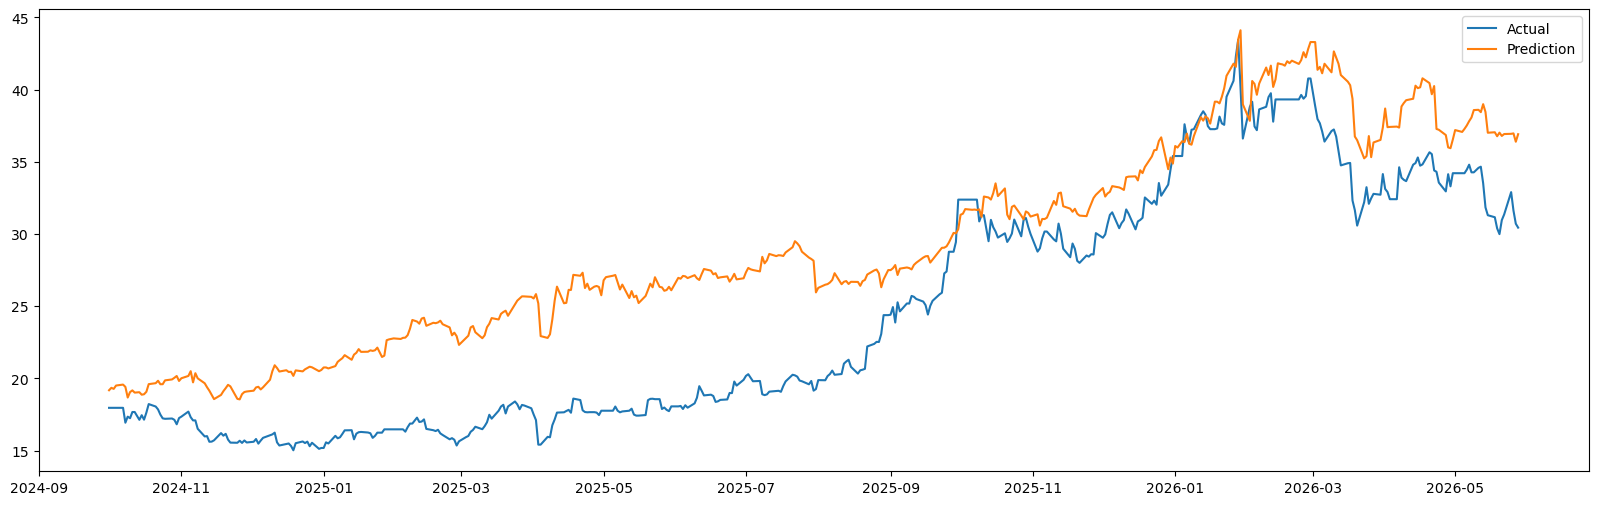

A_500                   1.118258
Dollar Index           -0.126247
cn_10y_rate            -0.871175
us_10y_rate             1.550746
brent                  -0.026774
Copper Futures Price    0.633330
Gold Futures Price      1.707011
归母净利润_单季               -0.463799
dtype: float64

In [27]:
# ===== 5. 最近三年作为训练集 =====
cutoff = pd.Timestamp("2024-09-30")
train_start = cutoff - pd.DateOffset(years=3)
test_end = pd.Timestamp("2026-05-31")

train_mask = (
    (X.index >= train_start)
    & (X.index <= cutoff)
    & (target_date <= cutoff)
)

test_mask = (
    (X.index > cutoff)
    & (X.index <= test_end)
    & (target_date <= test_end)
)

X_train = X.loc[train_mask]
Y_train = Y.loc[train_mask]

X_test = X.loc[test_mask]
Y_test = Y.loc[test_mask]

# 重新标准化、调参和拟合
Lasso_test(X_train, Y_train, X_test, Y_test)

效果更差了,看来是模型设计的问题.此外归母净利润系数变成负数,经济学上无法解释.  
此外,铜和金的系数显著改变,我们是否应该添加一下业务的构成比例?还有产量数据.

通过观察,紫金矿业的大涨一般伴随着放量.我们用平均的交易量与前一段时间的交易量的偏移值,来作为价格修正系数的一个信息,不知是否可行.

此外,因为业务构成比例,如果以收入的值而言,净利润本身就包含了金价的信息.更好的方法是产量,或者毛利润占比.

最终特征：
['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate', 'brent', 'Gold_business_exposure', 'Copper_business_exposure']

新加入的两个交互项：


,Gold_business_exposure,Copper_business_exposure
date,,
2012-05-09,689.000000,0.399251
2012-05-10,689.605269,0.402634
2012-05-11,684.633505,0.397997
2012-05-14,674.689977,0.387741
2012-05-15,673.047165,0.383759
2012-05-16,664.141180,0.379450
2012-05-17,680.699337,0.379559
2012-05-18,688.092123,0.378413
2012-05-21,686.708697,0.382068


训练集： (3349, 7)
测试集： (447, 7)

训练集最终特征：
['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate', 'brent', 'Gold_business_exposure', 'Copper_business_exposure']


,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Gold_business_exposure,Copper_business_exposure
date,,,,,,,
2024-09-24,1410.109436,100.370003,2.0728,3.74,75.29,700.188300,1.124870
2024-09-25,1429.055599,100.919998,2.0437,3.79,75.40,702.301119,1.124492
2024-09-26,1489.467659,100.559998,2.0787,3.79,73.06,705.127002,1.162181
2024-09-27,1560.147472,100.419998,2.1714,3.75,71.63,698.366019,1.159534
2024-09-29,1700.364180,100.779999,2.2534,3.81,72.35,696.200392,1.147811


RMSE： 5.217222038861437
R²： 0.6007458376062299


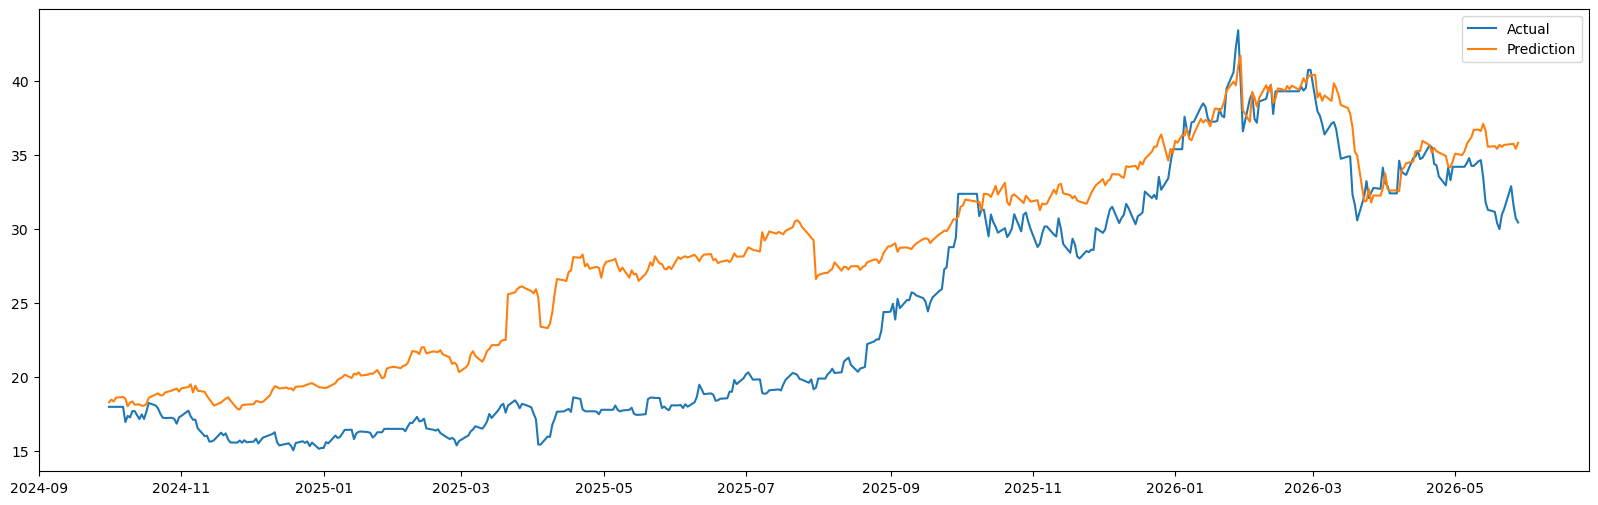

A_500                       1.280315
Dollar Index               -0.811202
cn_10y_rate                -1.270248
us_10y_rate                 2.157618
brent                      -0.473302
Gold_business_exposure      1.677646
Copper_business_exposure    1.572846
dtype: float64

In [32]:
# ============================================================
# 紫金矿业：
# 用“金价 × 黄金业务占比”和“铜价 × 铜业务占比”
# 替代原始金价和铜价，然后预测下一交易日股价
# ============================================================


# ===== 1. 导入依赖、定位项目目录 =====

import sys
from pathlib import Path
import pandas as pd


ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src/pickle/Dataset.pkl").exists()
)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.common import Lasso_test


# ============================================================
# 2. 读取原来的宏观变量和紫金矿业股价
# ============================================================

data_set = pd.read_pickle(
    ROOT / "src/pickle/Dataset.pkl"
)

X = data_set.X.copy()
Y = data_set.Y.copy()


# 统一日期格式
X.index = pd.to_datetime(X.index).normalize()
Y.index = pd.to_datetime(Y.index).normalize()

X = X.sort_index()
Y = Y.sort_index()


# 检查金价和铜价列是否存在
required_columns = [
    "Gold Futures Price",
    "Copper Futures Price"
]

missing = [
    col for col in required_columns
    if col not in X.columns
]

if missing:
    raise ValueError(
        f"X 中缺少以下列：{missing}"
    )


# ============================================================
# 3. 紫金矿业历年黄金、铜营业收入占比
# ============================================================

business_share = pd.DataFrame({

    "year": [
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
        2022,
        2023,
        2024,
        2025
    ],

    "gold_share": [
        0.6890,
        0.5939,
        0.5428,
        0.6143,
        0.7089,
        0.5999,
        0.4933,
        0.5082,
        0.5798,
        0.6132,
        0.4512,
        0.3841,
        0.4209,
        0.4964,
        0.4443
    ],

    "copper_share": [
        0.1091,
        0.1825,
        0.2754,
        0.2302,
        0.1557,
        0.1911,
        0.2235,
        0.1990,
        0.1922,
        0.1935,
        0.2428,
        0.2477,
        0.2521,
        0.2798,
        0.2762
    ]
})


# ============================================================
# 4. 设置业务占比的可用时间
# ============================================================

# 为避免未来信息泄漏：
#
# 例如：
# 2023年的全年业务占比
# 不应该用于2023年的预测。
#
# 这里采取保守处理：
# 每年数据从下一年5月1日开始使用。
#
# 2023业务占比 -> 2024-03-21开始使用
# 2024业务占比 -> 2025-05-21开始使用

business_share["available_from"] = pd.to_datetime(
    (business_share["year"] + 1).astype(str)
    + "-03-21"
)

business_share = business_share.sort_values(
    "available_from"
)


# ============================================================
# 5. 将业务占比加入日频数据
# ============================================================

X = pd.merge_asof(

    X.rename_axis("date")
     .reset_index()
     .sort_values("date"),

    business_share[
        [
            "available_from",
            "gold_share",
            "copper_share"
        ]
    ],

    left_on="date",
    right_on="available_from",

    direction="backward"
)


X = X.set_index("date")


# ============================================================
# 6. 创建金价 × 黄金业务占比
# ============================================================

X["Gold_business_exposure"] = (
    X["Gold Futures Price"]
    * X["gold_share"]
)


# ============================================================
# 7. 创建铜价 × 铜业务占比
# ============================================================

X["Copper_business_exposure"] = (
    X["Copper Futures Price"]
    * X["copper_share"]
)


# ============================================================
# 8. 删除原始变量
# ============================================================

# 删除：
#
# 原始金价
# 原始铜价
# 黄金占比
# 铜占比
# 辅助日期变量
#
# 最终只留下两个交互项

X = X.drop(
    columns=[
        "Gold Futures Price",
        "Copper Futures Price",
        "gold_share",
        "copper_share",
        "available_from"
    ]
)


# ============================================================
# 9. 检查结果
# ============================================================

print("最终特征：")

print(
    X.columns.tolist()
)


print("\n新加入的两个交互项：")

display(
    X[
        [
            "Gold_business_exposure",
            "Copper_business_exposure"
        ]
    ].head(10)
)


# ============================================================
# 10. 今天的变量预测下一个交易日股价
# ============================================================

# 记录每个 X 所对应的预测目标日期
target_date = pd.Series(
    Y.index,
    index=Y.index
).shift(-1)


# 今天的数据 -> 下一交易日的股价
Y = Y.shift(-1).rename(
    "明日股价"
)


# ============================================================
# 11. X、Y 对齐并删除缺失值
# ============================================================

model_data = (
    X.join(Y)
     .replace([float("inf"), float("-inf")], pd.NA)
     .dropna()
)


X = model_data.drop(
    columns="明日股价"
)

Y = model_data[
    "明日股价"
]

target_date = target_date.reindex(
    X.index
)


# ============================================================
# 12. 划分训练集 / 测试集
# ============================================================

cutoff = pd.Timestamp(
    "2024-09-30"
)

test_end = pd.Timestamp(
    "2026-05-31"
)


# --------------------------
# 训练集
# --------------------------

# 不仅 X 日期不能超过 cutoff，
# Y 对应的下一交易日也不能超过 cutoff

train_mask = (
    (X.index <= cutoff)
    &
    (target_date <= cutoff)
)


# --------------------------
# 测试集
# --------------------------

test_mask = (
    (X.index > cutoff)
    &
    (X.index <= test_end)
    &
    (target_date <= test_end)
)


X_train = X.loc[
    train_mask
]

Y_train = Y.loc[
    train_mask
]


X_test = X.loc[
    test_mask
]

Y_test = Y.loc[
    test_mask
]


# ============================================================
# 13. 查看训练集和测试集
# ============================================================

print(
    "训练集：",
    X_train.shape
)

print(
    "测试集：",
    X_test.shape
)


print(
    "\n训练集最终特征："
)

print(
    X_train.columns.tolist()
)


display(
    X_train.tail()
)


# ============================================================
# 14. 使用你原来的 Lasso 模型
# ============================================================

# Lasso_test 内部已经包含：
#
# StandardScaler
# TimeSeriesSplit
# GridSearchCV
# Lasso
# RMSE
# R²
#
# 所以这里直接调用即可

Lasso_test(
    X_train,
    Y_train,
    X_test,
    Y_test
)

训练集： (3349, 7)
测试集： (179, 7)

训练集最终特征：
['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate', 'brent', 'Gold_business_exposure', 'Copper_business_exposure']


,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Gold_business_exposure,Copper_business_exposure
date,,,,,,,
2024-09-24,1410.109436,100.370003,2.0728,3.74,75.29,700.188300,1.124870
2024-09-25,1429.055599,100.919998,2.0437,3.79,75.40,702.301119,1.124492
2024-09-26,1489.467659,100.559998,2.0787,3.79,73.06,705.127002,1.162181
2024-09-27,1560.147472,100.419998,2.1714,3.75,71.63,698.366019,1.159534
2024-09-29,1700.364180,100.779999,2.2534,3.81,72.35,696.200392,1.147811


RMSE： 2.2571233415453715
R²： 0.594309593681561


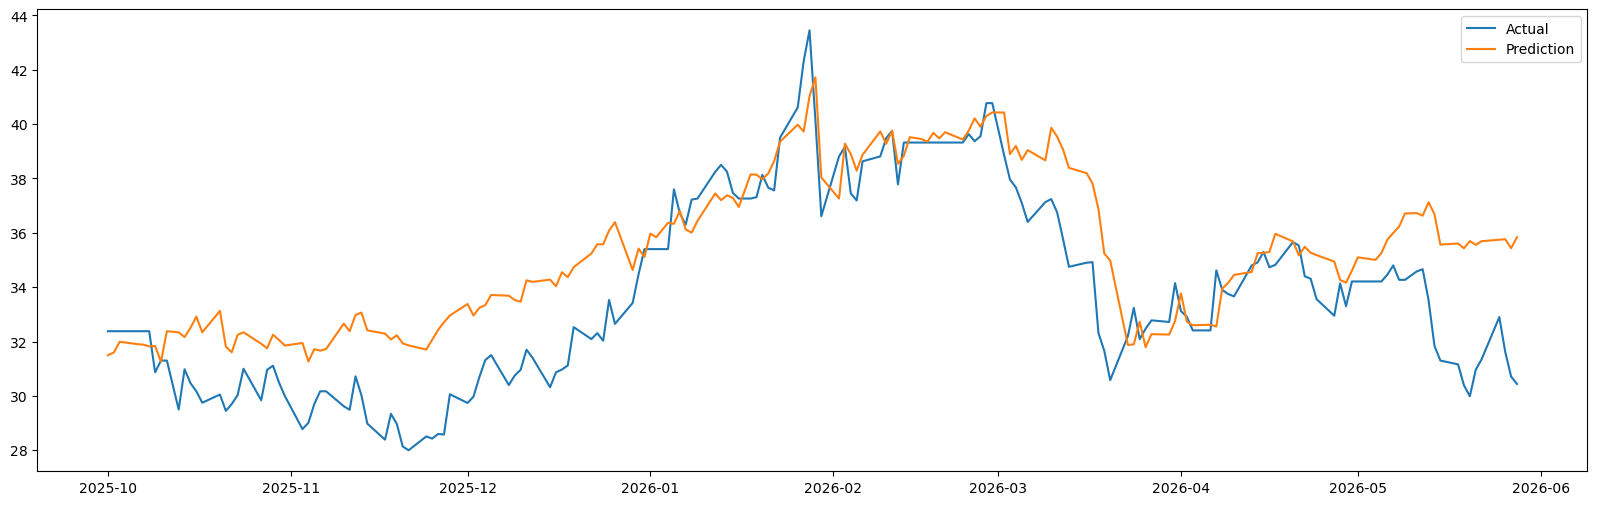

A_500                       1.280315
Dollar Index               -0.811202
cn_10y_rate                -1.270248
us_10y_rate                 2.157618
brent                      -0.473302
Gold_business_exposure      1.677646
Copper_business_exposure    1.572846
dtype: float64

In [34]:
# ============================================================
# 12. 划分训练集 / 测试集
# ============================================================

cutoff = pd.Timestamp(
    "2024-09-30"
)

test_end = pd.Timestamp(
    "2026-05-31"
)


# --------------------------
# 训练集
# --------------------------

# 不仅 X 日期不能超过 cutoff，
# Y 对应的下一交易日也不能超过 cutoff

train_mask = (
    (X.index <= cutoff)
    &
    (target_date <= cutoff)
)


# --------------------------
# 测试集
# --------------------------

test_mask = (
    (X.index > pd.Timestamp(
    "2025-09-30"
))
    &
    (X.index <= test_end)
    &
    (target_date <= test_end)
)


X_train = X.loc[
    train_mask
]

Y_train = Y.loc[
    train_mask
]


X_test = X.loc[
    test_mask
]

Y_test = Y.loc[
    test_mask
]


# ============================================================
# 13. 查看训练集和测试集
# ============================================================

print(
    "训练集：",
    X_train.shape
)

print(
    "测试集：",
    X_test.shape
)


print(
    "\n训练集最终特征："
)

print(
    X_train.columns.tolist()
)


display(
    X_train.tail()
)


# ============================================================
# 14. 使用你原来的 Lasso 模型
# ============================================================

# Lasso_test 内部已经包含：
#
# StandardScaler
# TimeSeriesSplit
# GridSearchCV
# Lasso
# RMSE
# R²
#
# 所以这里直接调用即可

Lasso_test(
    X_train,
    Y_train,
    X_test,
    Y_test
)

选取了两个不同时间段,但是加上了业务的占比信息,R^2从0.8下降到了0.6,看来这样构建也不可以.

预测的实际值到实际股价,是否存在一段时间的偏差?比如说6-12个月.进行一次试验.

预测周期： 126 个交易日
训练集： (3224, 7)
测试集： (322, 7)

示例：
        特征日期     预测目标日期  半年后股价
0 2012-05-09 2012-10-31   3.88
1 2012-05-10 2012-11-01   3.87
2 2012-05-11 2012-11-02   3.84
3 2012-05-14 2012-11-05   3.87
4 2012-05-15 2012-11-06   3.92
RMSE： 4.596967594581363
R²： 0.6372590812834569


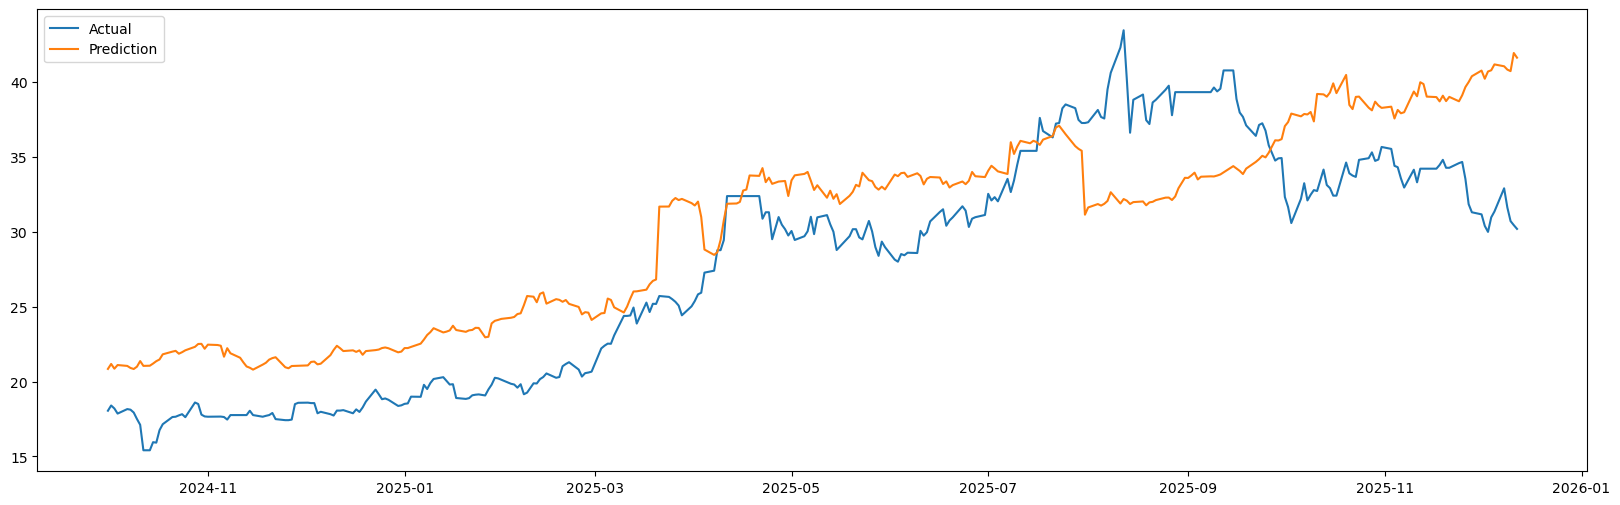

A_500                      -0.051995
Dollar Index                0.424403
cn_10y_rate                -0.782578
us_10y_rate                 1.651863
brent                      -1.315530
Gold_business_exposure      2.370460
Copper_business_exposure    2.487068
dtype: float64

In [35]:
# ============================================================
# 检验：今天的特征是否能预测半年后的紫金矿业股价
# ============================================================

import pandas as pd


# 半年大约 126 个交易日
lag_days = 126


# ------------------------------------------------------------
# 1. 确保日期排序正确
# ------------------------------------------------------------

X = X.sort_index()
Y = Y.sort_index()


# ------------------------------------------------------------
# 2. 构造半年后的股价
# ------------------------------------------------------------
# 当前：
# X_t
#
# 对应：
# Y_(t+126)

Y_future = Y.shift(-lag_days).rename("半年后股价")


# 同时记录真正对应的目标日期
target_date = pd.Series(
    Y.index,
    index=Y.index
).shift(-lag_days)


# ------------------------------------------------------------
# 3. X 和半年后的 Y 对齐
# ------------------------------------------------------------

model_data = X.join(Y_future).dropna()

X_lag = model_data.drop(
    columns="半年后股价"
)

Y_lag = model_data[
    "半年后股价"
]

target_date = target_date.reindex(
    X_lag.index
)


# ------------------------------------------------------------
# 4. 训练集 / 测试集划分
# ------------------------------------------------------------

cutoff = pd.Timestamp("2024-09-30")
test_end = pd.Timestamp("2026-05-31")


# 注意：
# 不仅 X 本身必须在训练期，
# 它所对应的半年后股价也必须在训练期
#
# 否则就会产生未来信息泄漏

train_mask = (
    (X_lag.index <= cutoff)
    &
    (target_date <= cutoff)
)


test_mask = (
    (X_lag.index > cutoff)
    &
    (X_lag.index <= test_end)
    &
    (target_date <= test_end)
)


X_train = X_lag.loc[train_mask]
Y_train = Y_lag.loc[train_mask]

X_test = X_lag.loc[test_mask]
Y_test = Y_lag.loc[test_mask]


# ------------------------------------------------------------
# 5. 查看数据
# ------------------------------------------------------------

print("预测周期：", lag_days, "个交易日")
print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

print("\n示例：")
print(
    pd.DataFrame({
        "特征日期": X_lag.index[:5],
        "预测目标日期": target_date.iloc[:5].values,
        "半年后股价": Y_lag.iloc[:5].values
    })
)


# ------------------------------------------------------------
# 6. 使用你原来的 Lasso 模型测试
# ------------------------------------------------------------

Lasso_test(
    X_train,
    Y_train,
    X_test,
    Y_test
)

看来这个理论也不对,并没有呈现重合的样子.

In [36]:
zijin

,open,high,low,close,volume,amount,outstanding_share,turnover
date,,,,,,,,
2012-05-02,4.35,4.44,4.31,4.40,103994416.0,4.565610e+08,1.580380e+10,0.006580
2012-05-03,4.38,4.40,4.35,4.37,57981480.0,2.532650e+08,1.580380e+10,0.003669
2012-05-04,4.33,4.38,4.31,4.38,58086300.0,2.524024e+08,1.580380e+10,0.003675
2012-05-07,4.34,4.40,4.32,4.39,64803776.0,2.836709e+08,1.580380e+10,0.004101
2012-05-08,4.38,4.39,4.34,4.38,62989116.0,2.745420e+08,1.580380e+10,0.003986
...,...,...,...,...,...,...,...,...
2026-07-20,28.36,29.45,28.29,29.35,275768250.0,7.992030e+09,2.060179e+10,0.013386
2026-07-21,29.95,30.33,29.13,30.21,342666967.0,1.019429e+10,2.060179e+10,0.016633
2026-07-22,30.81,32.79,30.81,32.20,526165813.0,1.685158e+10,2.060179e+10,0.025540


在这里,我们使用turnover,来作为交易量活跃的判断.  
我们采用交易量的相对变化,根据计算出来的预测值,乘以这个修正值,看是否可以解释.

,turnover,turnover_ma5,turnover_ratio5,turnover_ma5_scaled,k
2012-05-10,0.003735,0.003833,-0.025618,0.720965,0.969962
2012-05-11,0.002638,0.003627,-0.272701,0.719274,0.932115
2012-05-14,0.003191,0.003530,-0.095950,0.718480,0.961422
2012-05-15,0.003315,0.003373,-0.017087,0.717192,1.030751
2012-05-16,0.002619,0.003100,-0.155076,0.714950,1.046994


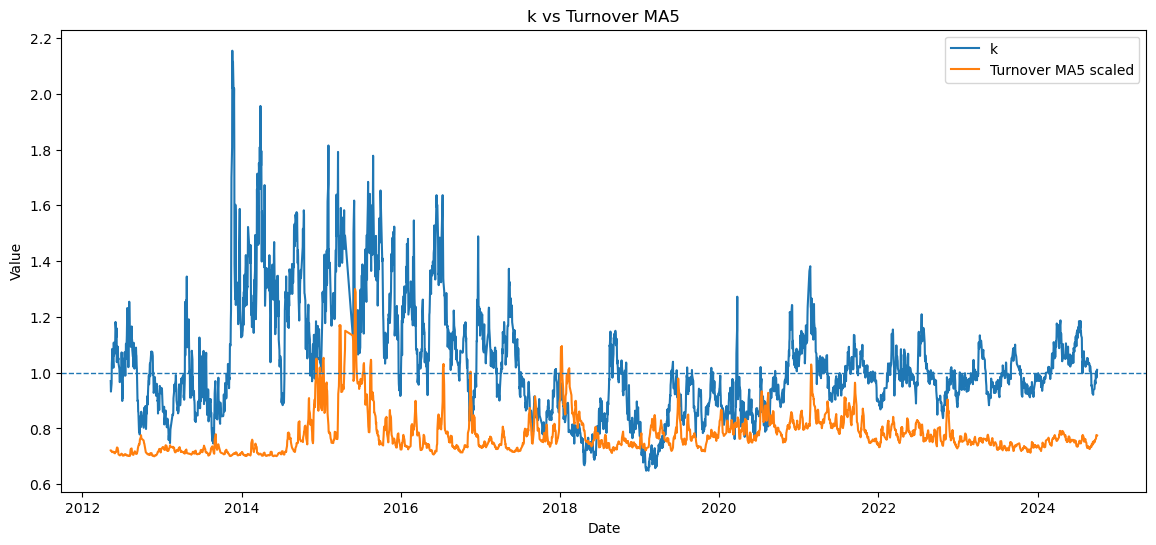

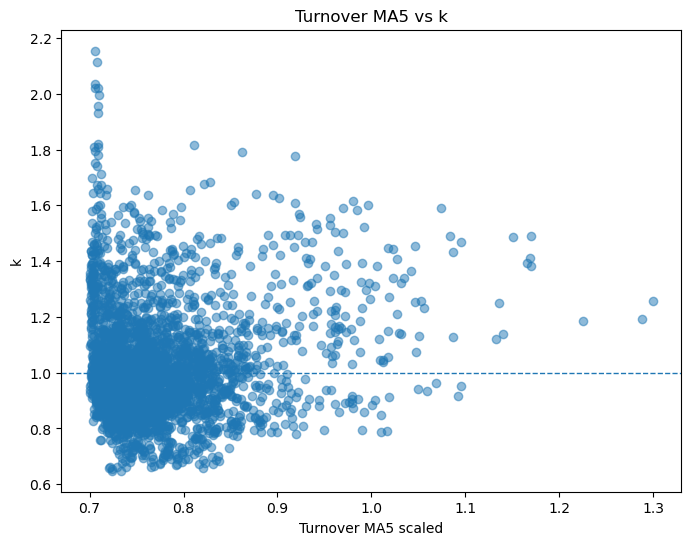

,turnover_ma5_scaled,k
turnover_ma5_scaled,1.000000,0.083163
k,0.083163,1.000000


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


# ============================================================
# 1. 读取已有数据
# ============================================================

stock_data = pd.read_pickle('./data/stock_data.pkl')

stocks = {}

for name, frame in stock_data.items():
    frame = frame.copy()
    frame['date'] = pd.to_datetime(frame['date'])

    stocks[name] = (
        frame
        .set_index('date')
        .sort_index()
    )

zijin = stocks['紫金矿业']


# ============================================================
# 2. 计算换手率 5 日 MA
# ============================================================

turnover = zijin['turnover']

turnover_ma5 = (
    turnover
    .rolling(5)
    .mean()
)


# ============================================================
# 3. 计算换手率相对于 MA5 的变化
# ============================================================
#
# > 0 ：当前换手率高于过去5日平均
# < 0 ：当前换手率低于过去5日平均
#

turnover_ratio5 = (
    turnover / turnover_ma5 - 1
)


# ============================================================
# 4. 上一交易日信息 → 当天的 k
# ============================================================
#
# result_train / result_test 的日期是“被预测日期”
# 因此使用前一交易日已经知道的换手率信息
#

turnover_data = pd.DataFrame({
    'turnover': turnover,
    'turnover_ma5': turnover_ma5,
    'turnover_ratio5': turnover_ratio5
})

turnover_data = turnover_data.shift(1)


# ============================================================
# 5. 与已经算好的 k 对齐
# ============================================================

train_k = turnover_data.join(
    result_train[['k']],
    how='inner'
)

test_k = turnover_data.join(
    result_test[['k']],
    how='inner'
)


train_k = (
    train_k
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

test_k = (
    test_k
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)


# ============================================================
# 6. 把 MA5 压缩到 0.7 ～ 1.3
# ============================================================
#
# 注意：
# scaler只在训练集 fit
# 避免测试集信息进入训练过程
#

scaler = MinMaxScaler(
    feature_range=(0.7, 1.3)
)

train_k['turnover_ma5_scaled'] = scaler.fit_transform(
    train_k[['turnover_ma5']]
)

test_k['turnover_ma5_scaled'] = scaler.transform(
    test_k[['turnover_ma5']]
)


# ============================================================
# 7. 查看结果
# ============================================================

display(
    train_k[
        [
            'turnover',
            'turnover_ma5',
            'turnover_ratio5',
            'turnover_ma5_scaled',
            'k'
        ]
    ].head()
)


# ============================================================
# 8. 画 k 和压缩后的换手率 MA5
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    train_k.index,
    train_k['k'],
    label='k'
)

plt.plot(
    train_k.index,
    train_k['turnover_ma5_scaled'],
    label='Turnover MA5 scaled'
)

plt.axhline(
    1,
    linestyle='--',
    linewidth=1
)

plt.legend()
plt.title('k vs Turnover MA5')
plt.xlabel('Date')
plt.ylabel('Value')

plt.show()


# ============================================================
# 9. 散点图：观察二者关系
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    train_k['turnover_ma5_scaled'],
    train_k['k'],
    alpha=0.5
)

plt.axhline(
    1,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Turnover MA5 scaled')
plt.ylabel('k')

plt.title('Turnover MA5 vs k')

plt.show()


# ============================================================
# 10. 简单看相关系数
# ============================================================

corr = train_k[
    [
        'turnover_ma5_scaled',
        'k'
    ]
].corr()

display(corr)

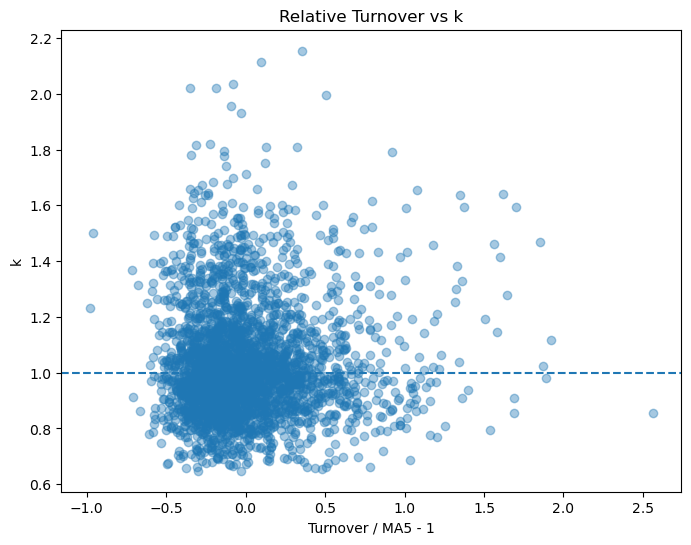

                 turnover_ratio5         k
turnover_ratio5         1.000000  0.022217
k                       0.022217  1.000000


In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    train_k['urnover / MA5 - 1'],
    train_k['k'],
    alpha=0.4
)

plt.axhline(1, linestyle='--')

plt.xlabel('Turnover / MA5 - 1')
plt.ylabel('k')
plt.title('Relative Turnover vs k')

plt.show()


print(
    train_k[
        ['turnover_ratio5', 'k']
    ].corr()
)

换手率与预测偏离值的关系很弱,应该无法解释.也证明了上面,用换手率作为因子,系数被压为0的结论.

## 总结  
如果想要用我们宏观变量得到一个基准值,乘以一个系数来得到实际值,只有波动性略微有一点用.目前看来这个方法不可行.MACD,RSI并没有用.  
在模型中加入一些基本面要素,如扣非净利润,由于定期报告的值较为固定,所以模型应该会更加稳定,但是目前最大的问题是模型的大幅波动无法解释.  
训练集应该尽可能的大,如果觉得情况有变,将训练集缩小,可能学到的系数才是特殊情况,用于预测效果更差.  
对收入进行比例划分,给予金铜不同的权重,并不会让预测更加准确.  
针对一些动量理论说的,股票预测值和实际值,可能有中期(6-12个月)的延迟,直接放弃这个说法.即使是真的,由于延迟时间的不确定,根本无法用于模型.  
